# 06b. Q_FIXED 민감도 + Expanding-Window 선택 — Baseline vol

## 목적
Baseline vol(현재 시점 `vol_21d` 직접 사용)을 기준으로 한 BL 포트폴리오에서 Q_FIXED 값에 따른 성과 변화를 분석하고, **expanding-window 방식**으로 최적 Q를 시점별로 선택하여 사후 선택 편향을 제거한다.

## 두 가지 평가 방식

| 방식 | 의미 | 편향 |
|------|------|------|
| **Pass 1 (per-Q in-sample)** | 모든 Q 후보로 walk-forward, 전체 OOS Sharpe로 최적 Q 선택 | **사후 선택 편향 있음** (참고용) |
| **Pass 2 (expanding-window)** | 매 시점 t에서 [0, t-1] 누적 Sharpe로 Q* 선택 → t 시점에 적용 | **편향 없음** (메인 결과) |

## 설계
- Vol 소스: **Baseline** (`vol_21d` 현재 실현변동성)
- Q 후보: `[0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]`
- 기간: 2010-01 ~ 2024-12 (180개월)
- Warmup: 초기 24개월은 Q_DEFAULT(0.003) 사용

## 출력
- `q_sensitivity_baseline_stats.csv` — Pass 1 per-Q 통계 (in-sample, 참고용)
- `q_expanding_baseline_returns.csv` — Pass 2 expanding-window 수익률 시계열
- `q_expanding_baseline_log.csv` — 매월 선택된 Q* + 후보별 누적 Sharpe
- `q_optimal_baseline` (스칼라, 노트북 내 변수) — 마지막 시점 Q* (다운스트림 99의 Q_FIXED 기본값)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '06b_Q_Sensitivity_Baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW  = 60
TAU           = 0.1
PCT_GROUP     = 0.30
START_PRED    = '2010-01-01'
END_PRED      = '2024-12-31'
Q_CANDIDATES  = [0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]
Q_DEFAULT     = 0.003
WARMUP        = 24

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()
rf_monthly = rf_series

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q 탐색 범위: {Q_CANDIDATES}')
print(f'Warmup: {WARMUP}개월 (Q_DEFAULT = {Q_DEFAULT})')

패널: (108135, 11)
예측 기간: 2010-01-31 ~ 2024-12-31 (180개월)
Q 탐색 범위: [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02]
Warmup: 24개월 (Q_DEFAULT = 0.003)


## Pass 1 — Walk-forward (Baseline vol, 모든 Q 후보)

In [2]:
results = {f'Q={q:.3f}': [] for q in Q_CANDIDATES}
results['CAPM'] = []
results['SPY']  = []

print(f'Pass 1 Walk-forward (Baseline vol_21d): {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam  = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        # Baseline: vol_21d 직접 사용
        P     = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        for q_val in Q_CANDIDATES:
            key   = f'Q={q_val:.3f}'
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[key].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        results['SPY'].append({'date': pred_date, 'ret': r_spy})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items() if v}
print(f'\nPass 1 완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')

Pass 1 Walk-forward (Baseline vol_21d): 2010-01-31 ~ 2024-12-31 (180개월)


  2010-12-31 (12/180)


  2011-12-31 (24/180)


  2012-12-31 (36/180)


  2013-12-31 (48/180)


...

  2021-12-31 (144/180)


  2022-12-31 (156/180)


  2023-12-31 (168/180)


  2024-12-31 (180/180)



Pass 1 완료
  Q=0.001: 180개월
  Q=0.002: 180개월
  Q=0.003: 180개월
  Q=0.005: 180개월
  Q=0.007: 180개월
  Q=0.010: 180개월
  Q=0.015: 180개월
  Q=0.020: 180개월
  CAPM: 180개월
  SPY: 180개월


## Pass 2 — Expanding-Window Q 선택

In [3]:
common_dates = ret_series[f"Q={Q_CANDIDATES[0]:.3f}"].index
sens_raw = {q: ret_series[f"Q={q:.3f}"].reindex(common_dates) for q in Q_CANDIDATES}

expanding_records = []
expanding_log     = []

for i, date in enumerate(common_dates):
    if i < WARMUP:
        q_use = Q_DEFAULT
        past_sharpes = {f'sharpe_Q={q:.3f}': np.nan for q in Q_CANDIDATES}
    else:
        past_sharpes = {}
        for q in Q_CANDIDATES:
            past_rets = sens_raw[q].iloc[:i]
            past_rf   = rf_monthly.reindex(past_rets.index).fillna(0)
            exc = past_rets - past_rf
            sh = exc.mean() / exc.std() * np.sqrt(12) if exc.std() > 0 else np.nan
            past_sharpes[f'sharpe_Q={q:.3f}'] = float(sh) if not np.isnan(sh) else np.nan
        valid = {q: past_sharpes[f"sharpe_Q={q:.3f}"] for q in Q_CANDIDATES
                 if not np.isnan(past_sharpes[f"sharpe_Q={q:.3f}"])}
        q_use = max(valid, key=valid.get) if valid else Q_DEFAULT

    this_ret = float(sens_raw[q_use].loc[date])
    expanding_records.append({'date': date, 'ret': this_ret, 'q_used': q_use})
    expanding_log.append({'date': date, 'q_used': q_use, **past_sharpes})

expanding_ret_df = pd.DataFrame(expanding_records).set_index('date')
expanding_log_df = pd.DataFrame(expanding_log).set_index('date')

Q_OPTIMAL_BASELINE = float(expanding_log_df['q_used'].iloc[-1])
q_use_counts = expanding_log_df["q_used"].value_counts().sort_index()

print('=' * 65)
print('Pass 2 Expanding-window 결과 (Baseline vol)')
print('=' * 65)
print(f'마지막 시점 Q* = {Q_OPTIMAL_BASELINE}')
print(f'\nQ* 시간 분포:')
for q, n in q_use_counts.items():
    print(f'  Q={q:.3f}: {n}개월 ({n/len(common_dates)*100:.1f}%)')

Pass 2 Expanding-window 결과 (Baseline vol)
마지막 시점 Q* = 0.005

Q* 시간 분포:
  Q=0.003: 104개월 (57.8%)
  Q=0.005: 47개월 (26.1%)
  Q=0.007: 29개월 (16.1%)


## 성과 비교 — In-Sample vs Expanding-Window

In [4]:
PER_Q_ORDER = [f"Q={q:.3f}" for q in Q_CANDIDATES] + ["CAPM", "SPY"]
per_q_stats = [performance(ret_series[k], rf_monthly, k)
               for k in PER_Q_ORDER if k in ret_series]
per_q_df = pd.DataFrame(per_q_stats).set_index('label')

per_q_bl   = per_q_df.drop(index=['CAPM', 'SPY'], errors='ignore')
Q_INSAMPLE = float(per_q_bl['sharpe'].idxmax().split('=')[1])
SH_INSAMPLE = per_q_bl['sharpe'].max()

exp_perf = performance(expanding_ret_df['ret'], rf_monthly, 'Expanding-Q')
exp_df   = pd.DataFrame([exp_perf]).set_index("label")
combined_df = pd.concat([per_q_df, exp_df])

disp = combined_df.copy()
for col in ['ann_ret', 'ann_vol', 'cum_ret', 'mdd']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['sharpe', 'calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)
disp.columns = ['연환산수익률', '연환산변동성', 'Sharpe', 'Calmar', '누적수익률', 'MDD']

print('=' * 80)
print('Baseline vol — Q_FIXED 민감도 (Pass 1) + Expanding-Q (Pass 2)')
print('=' * 80)
print(disp.to_string())
print()
print(f'★ in-sample 최적 Q (참고용, 편향): Q={Q_INSAMPLE:.3f}  Sharpe {SH_INSAMPLE:.3f}')
print(f'★ expanding-window 마지막 Q*       : Q={Q_OPTIMAL_BASELINE:.3f}  '
      f'Sharpe {exp_perf["sharpe"]:.3f}')

per_q_df.to_csv(OUT_DIR / 'q_sensitivity_baseline_stats.csv')
expanding_ret_df.to_csv(OUT_DIR / 'q_expanding_baseline_returns.csv')
expanding_log_df.to_csv(OUT_DIR / 'q_expanding_baseline_log.csv')
pd.DataFrame(ret_series).to_csv(OUT_DIR / 'q_sens_raw_baseline.csv')
print(f'\n저장: {OUT_DIR}/')


Baseline vol — Q_FIXED 민감도 (Pass 1) + Expanding-Q (Pass 2)
             연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD
label                                                      
Q=0.001      13.34%  12.18%  0.997  0.693  555.26%  -19.24%
Q=0.002      13.28%  11.79%  1.025  0.726  554.38%  -18.29%
Q=0.003      13.42%  11.59%  1.055  0.757  570.91%  -17.73%
Q=0.005      13.44%  11.39%  1.074  0.806  574.90%  -16.68%
Q=0.007      13.45%  11.42%  1.072  0.849  575.26%  -15.83%
Q=0.010      13.38%  11.56%  1.053  0.903  567.04%  -14.82%
Q=0.015      13.23%  11.95%  1.006  0.946  547.67%  -13.99%
Q=0.020      13.09%  12.30%  0.966  0.929  531.01%  -14.09%
CAPM         13.78%  14.74%  0.855  0.613  564.80%  -22.46%
SPY          14.45%  14.51%  0.916  0.604  638.27%  -23.93%
Expanding-Q  13.16%  11.40%  1.049  0.789  547.34%  -16.68%

★ in-sample 최적 Q (참고용, 편향): Q=0.005  Sharpe 1.074
★ expanding-window 마지막 Q*       : Q=0.005  Sharpe 1.049

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_p

## 시각화

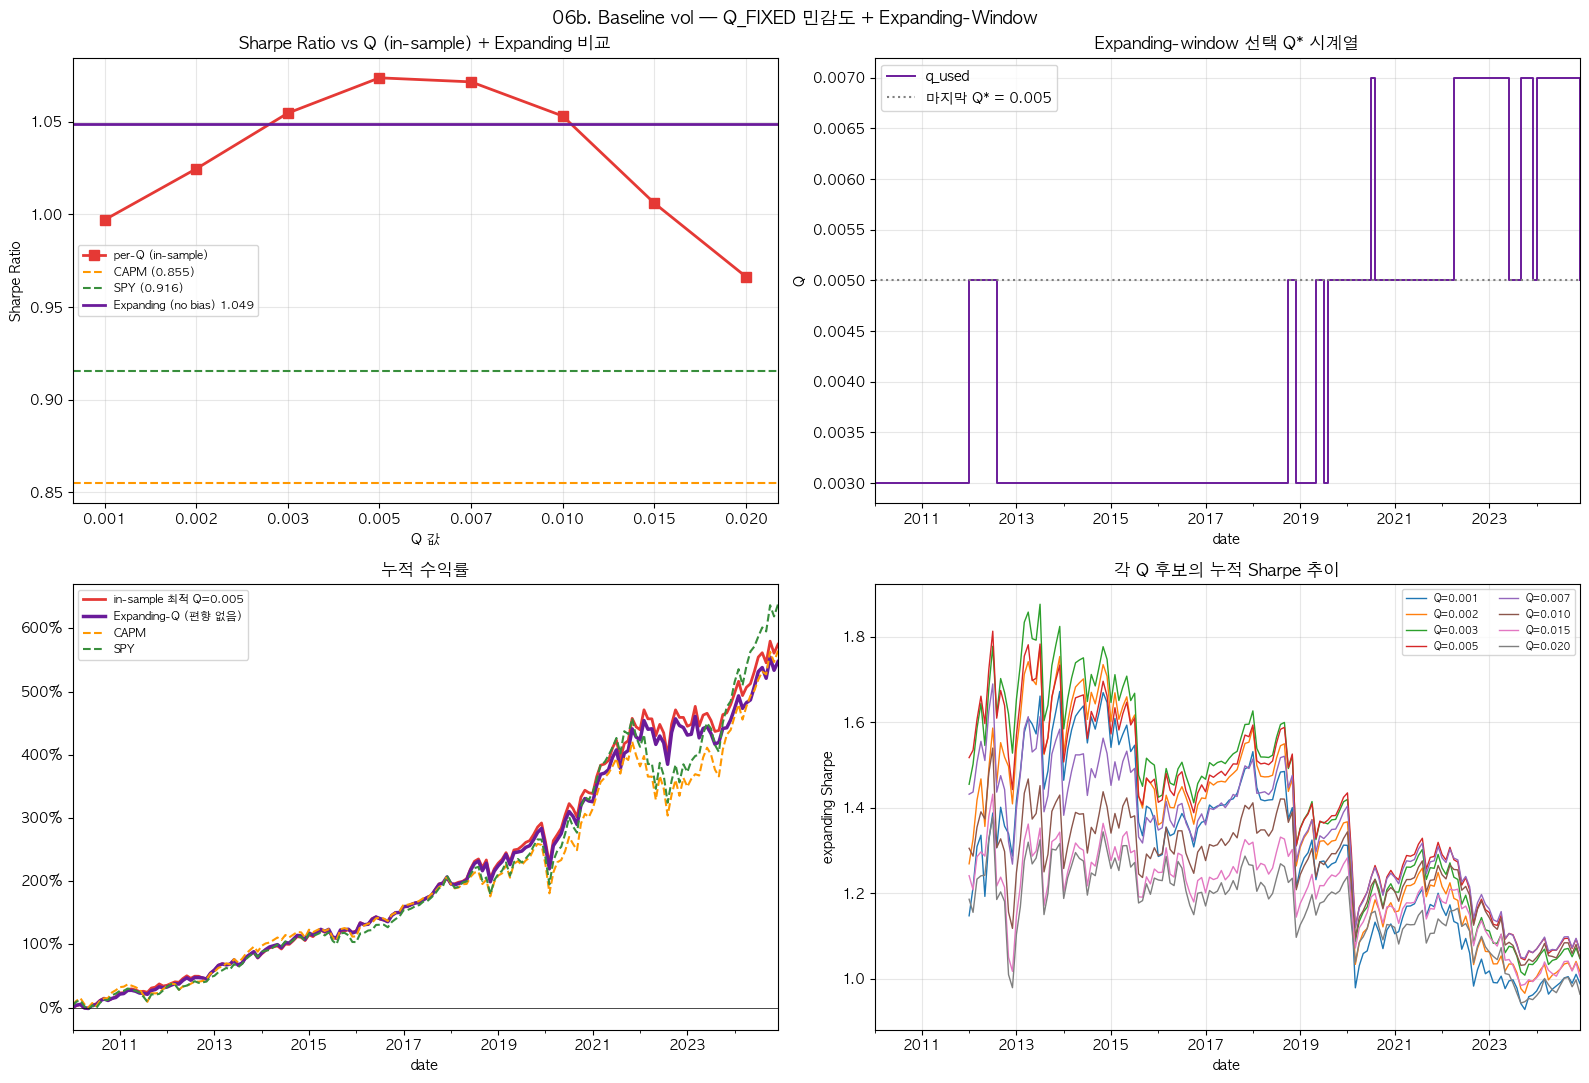


저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/06b_Q_Sensitivity_Baseline/q_sensitivity_baseline.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('06b. Baseline vol — Q_FIXED 민감도 + Expanding-Window', fontsize=13, fontweight='bold')

ax = axes[0, 0]
q_labels = [f'{q:.3f}' for q in Q_CANDIDATES]
sharpes  = [per_q_df.loc[f"Q={q:.3f}", "sharpe"] for q in Q_CANDIDATES]
ax.plot(q_labels, sharpes, 's-', color='#E53935', linewidth=2, markersize=7, label='per-Q (in-sample)')
ax.axhline(per_q_df.loc['CAPM', 'sharpe'], color='#FF9800', ls='--', label=f'CAPM ({per_q_df.loc["CAPM", "sharpe"]:.3f})')
ax.axhline(per_q_df.loc['SPY', 'sharpe'],  color='#388E3C', ls='--', label=f'SPY ({per_q_df.loc["SPY", "sharpe"]:.3f})')
ax.axhline(exp_perf['sharpe'], color='#6A1B9A', linewidth=2.0, label=f'Expanding (no bias) {exp_perf["sharpe"]:.3f}')
ax.set_title('Sharpe Ratio vs Q (in-sample) + Expanding 비교')
ax.set_xlabel('Q 값'); ax.set_ylabel('Sharpe Ratio'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
expanding_log_df['q_used'].plot(ax=ax, drawstyle='steps-post', color='#6A1B9A', linewidth=1.4)
ax.axhline(Q_OPTIMAL_BASELINE, color='gray', ls=':', label=f'마지막 Q* = {Q_OPTIMAL_BASELINE}')
ax.set_title('Expanding-window 선택 Q* 시계열')
ax.set_ylabel('Q'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
(1 + ret_series[f'Q={Q_INSAMPLE:.3f}']).cumprod().sub(1).plot(
    ax=ax, label=f'in-sample 최적 Q={Q_INSAMPLE:.3f}', color='#E53935', linewidth=2)
(1 + expanding_ret_df['ret']).cumprod().sub(1).plot(
    ax=ax, label='Expanding-Q (편향 없음)', color='#6A1B9A', linewidth=2.5)
(1 + ret_series['CAPM']).cumprod().sub(1).plot(ax=ax, label='CAPM', color='#FF9800', ls='--', linewidth=1.5)
(1 + ret_series['SPY']).cumprod().sub(1).plot(ax=ax, label='SPY',  color='#388E3C', ls='--', linewidth=1.5)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8); ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1, 1]
for q in Q_CANDIDATES:
    col = f"sharpe_Q={q:.3f}"
    expanding_log_df[col].plot(ax=ax, label=f'Q={q:.3f}', linewidth=1.0)
ax.set_title('각 Q 후보의 누적 Sharpe 추이')
ax.set_ylabel('expanding Sharpe')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_sensitivity_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n저장: {OUT_DIR}/q_sensitivity_baseline.png')